# Kaggle - Brain Tumor MRI Dataset

You can find the dataset and some informations about on the [Kaggle page](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

For details on steps below, please see documentation in the *docs* directory.

## Kaggle notebook setup
### Installations

In [5]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 85.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

### Data location

In [6]:
import os
print(os.listdir('/kaggle/input/'))
print(os.listdir('/kaggle/input/radimagenet-densenet121-notop'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed/processed'))
print(os.listdir('/kaggle/input/brain-tumor-heads-weights'))

['brain-tumor-heads-weights', 'brain-tumor-mri-preprocessed', 'radimagenet-densenet121-notop']
['RadImageNet-DenseNet121_notop.h5']
['processed']
['Validation', 'Training', 'Testing', '.gitkeep']
['brain_tumor_heads.weights.h5']


## General

In [7]:
import mlflow
import mlflow.tensorflow
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri("https://preachingly-nonabjuratory-marget.ngrok-free.dev")
mlflow.set_experiment("Brain_Tumor_Training")

2026-02-17 14:19:56.016721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771337996.196503      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771337996.246395      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771337996.673902      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771337996.673945      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771337996.673948      55 computation_placer.cc:177] computation placer alr

<Experiment: artifact_location='mlflow-artifacts:/830660600119881173', creation_time=1769099937797, experiment_id='830660600119881173', last_update_time=1769099937797, lifecycle_stage='active', name='Brain_Tumor_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [8]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import math

import cv2
from collections import defaultdict
from typing import Tuple, Optional, Union

In [9]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

Num GPUs Available: 1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [10]:
# path management
PROJECT_ROOT = '/kaggle/input'
PREP_DIR = PROJECT_ROOT + '/brain-tumor-mri-preprocessed/processed'
ARTEFACTS_DIR = PROJECT_ROOT + '/radimagenet-densenet121-notop'
BEST_HEAD_DIR = PROJECT_ROOT + '/brain-tumor-heads-weights'
OUTPUT_DIR = "kaggle/working/radcam_results"
os.makedirs(OUTPUT_DIR + "/correct", exist_ok=True)
os.makedirs(OUTPUT_DIR + "/errors", exist_ok=True)

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_DIR = "/kaggle/working/export_model"
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES = ["notumor", "glioma", "meningioma", "pituitary"]

# model parameters
IMG_SIZE = 260
SEED = 42

PROJECT_NAME = "BrainTumorMRI"
MODEL_TYPE = "DenseNet121"
TWO_HEAD = True
MODEL_NAME = f"{PROJECT_NAME}_{MODEL_TYPE}_{TWO_HEAD*"2Head"}"
FREEZE_BACKBONE = True
MASK_TUMOR_TYPE_LOSS = True
BATCH_SIZE = 32
DATA_AUGMENTATION = True

## Modeling

### Backbone

In [11]:
def get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    # 1. Create DenseNet121 WITHOUT weights
    backbone = DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # 2. Load RadImageNet weights
    backbone.load_weights(ARTEFACTS_DIR + "/RadImageNet-DenseNet121_notop.h5")
    
    # 3. Freeze the backbone for firsts training
    backbone.trainable = not FREEZE_BACKBONE
    
    print("✅ RadImageNet DenseNet121 loaded successfully")
    
    return backbone

In [12]:
backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)

I0000 00:00:1771338009.594663      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ RadImageNet DenseNet121 loaded successfully


In [13]:
#backbone.summary()

In [14]:
w = backbone.weights[0].numpy()
print("Mean:", np.mean(w), "Std:", np.std(w))

Mean: -0.0028284893 Std: 0.10494729


Model seems to be correctly loaded.

### Model definition

In [15]:
def get_model_data_augmentation(x):
    x = layers.RandomFlip("horizontal", seed=SEED)(x)
    x = layers.RandomZoom((-0.03,0.03),(-0.03,0.03), seed=SEED)(x)
    x = layers.RandomTranslation((-0.01,0.01),(-0.01,0.01), seed=SEED)(x)
    return x

In [16]:
def get_model_head_presence(x):
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1,activation='sigmoid',name="tumor_presence")(x)
    return x

In [17]:
def get_model_head_type(x):
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(4,activation='softmax',name="tumor_type")(x)
    return x

In [18]:
def shared_head_part(inputs, backbone):
    # Data augmentation (training only)
    x = get_model_data_augmentation(inputs)
    # Backbone - force into inference
    x = backbone(x, training=False)

    # Copy backbone output exactly via Lambda (no trainable params)
    #x = layers.Lambda(lambda t: t, name='Top_Conv_Layer')(x)    
    x = layers.Conv2D(64, 3, strides=1, padding='same', activation='relu', name='Top_Conv_Layer', trainable=False)(x)
    
    # Shared head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    return x

In [19]:
def assemble_heads(IMG_SIZE, backbone):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = shared_head_part(inputs, backbone)
    
    #Heads
    output_presence = get_model_head_presence(x)
    output_type = get_model_head_type(x)
    
    model = keras.Model(
        inputs=inputs,
        outputs={
            "tumor_presence": output_presence,
            "tumor_type": output_type
        },
        name='densenet_two_head'
    )

    return model

In [20]:
def get_loss_presence():
    return keras.losses.BinaryFocalCrossentropy(
        gamma=2.0,
        alpha=0.25 # to favorize tumor detection (penalize false negatives), but taking account that tumors are 75% of data
    )

In [21]:
#@keras.saving.register_keras_serializable()
@tf.keras.utils.register_keras_serializable()
def masked_sparse_cce(y_true, y_pred):
    tumor_present = tf.cast(y_true != 0, tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    loss = loss * tumor_present
    return tf.reduce_sum(loss) / (tf.reduce_sum(tumor_present) + 1e-6)

In [22]:
def compile_model(model, masked_sparse_cce):
    loss_presence = get_loss_presence()
    
    loss_weight_presence = 1.0
    loss_weight_type = 1.3 # we give a little more weight to the classification of the type
    
    model.compile(
        optimizer=keras.optimizers.Adam(), # change learning_rate for 1e-4 in fine-tuning steps
        loss={
            "tumor_presence": loss_presence,
            "tumor_type": masked_sparse_cce,
        },
        
        loss_weights={
            "tumor_presence": loss_weight_presence,
            "tumor_type": loss_weight_type, 
        },
        
        metrics={
            "tumor_presence": [
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.Recall(name="recall"),
                keras.metrics.Precision(name="precision"),
                #keras.metrics.F1Score(name="f1_score"),
                keras.metrics.AUC(name="auc")
            ],
            "tumor_type": [
                "accuracy", 
                #"f1_score"
            ],
        }
    )

    return model, loss_weight_presence, loss_weight_type

In [23]:
def get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    
    backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
    model = assemble_heads(IMG_SIZE, backbone)

    return model

In [24]:
model = get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
model, loss_weight_presence, loss_weight_type = compile_model(model, masked_sparse_cce)

✅ RadImageNet DenseNet121 loaded successfully


In [25]:
#model.summary()

## Streaming Training

In [26]:
def parse_tfrecord(example_proto):
    """
    Parse a single TFRecord example and convert grayscale → RGB.
    """
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }

    example = tf.io.parse_single_example(example_proto, feature_description)

    # Deserialize image
    image = tf.io.parse_tensor(example["image"], out_type=tf.float32)

    # Shape after loading: (260, 260, 3)
    image.set_shape((260, 260, 3))

    label = tf.cast(example["label"], tf.int32)

    return image, label



def load_tfrecord_dataset(tfrecord_dir, shuffle=False, batch_size=1, repeat=False):
    """
    Load a TFRecord dataset from a directory.

    Args:
        tfrecord_dir (str or Path): Folder containing .tfrecord files
        shuffle (bool): Whether to shuffle files and samples
        batch_size (int): Batch size (can stay 1)
        repeat (bool): Repeat dataset indefinitely (for training)

    Returns:
        tf.data.Dataset
    """
    tfrecord_files = tf.io.gfile.glob(
        str(tfrecord_dir) + "/*.tfrecord"
    )

    ds = tf.data.TFRecordDataset(
        tfrecord_files,
        num_parallel_reads=tf.data.AUTOTUNE
    )

    ds = ds.map(
        parse_tfrecord,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=512)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [27]:
TRAIN_DIR = PREP_DIR + "/Training"
VAL_DIR   = PREP_DIR + "/Validation"
TEST_DIR  = PREP_DIR + "/Testing"

train_ds = load_tfrecord_dataset(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

"""
test_ds = load_tfrecord_dataset(
    TEST_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)
"""

'\ntest_ds = load_tfrecord_dataset(\n    TEST_DIR,\n    shuffle=False,\n    batch_size=BATCH_SIZE,\n    repeat=False\n).prefetch(tf.data.AUTOTUNE)\n'

In [28]:
def split_labels(image, label):
    """
    Create labels for a 2-head model.
    """
    tumor_present = tf.cast(label != 0, tf.float32)
    tumor_type = tf.cast(label, tf.int32)

    return image, {
        "tumor_presence": tumor_present,
        "tumor_type": tumor_type
    }


In [29]:
train_ds = train_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [30]:
#for x, y in train_ds.take(1):
#    print("Image:")
#    print(x.dtype, x.shape)
#    print("\nLabels:")
#    for k, v in y.items():
#        print(k, v.dtype, v.shape)

In [31]:
def count_tfrecord_batches(directory_path, batch_size):
    """
    Count number of batches for a TFRecord dataset.

    Assumes:
    - 1 sample per TFRecord
    - batch_size is variable

    Returns:
    - number of batches = ceil(num_samples / batch_size)
    """
    directory_path = Path(directory_path)
    n_samples = len(list(directory_path.glob("*.tfrecord")))
    return math.ceil(n_samples / batch_size)


In [32]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name=None), {'tumor_presence': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'tumor_type': TensorSpec(shape=(None,), dtype=tf.int32, name=None)})


In [33]:
#to_monitor = "val_tumor_presence_recall"
#mode = "max"
to_monitor = "val_tumor_type_loss"
mode = "min"

reduce_lr = ReduceLROnPlateau(
    monitor=to_monitor,
    mode=mode,
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor=to_monitor,
    mode=mode,
    min_delta=0.00001,
    patience=10,
    restore_best_weights=False,
    verbose=1,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR + "/epoch_{epoch:02d}.weights.h5",
    monitor=to_monitor,
    mode=mode,
    save_best_only=False,
    save_weights_only=True,
    verbose=1,
)

terminate_nan = keras.callbacks.TerminateOnNaN()

In [34]:
#print("RUN_NAME:", RUN_NAME)
#print("TRAIN steps:", count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE))
#print("VAL steps:", count_tfrecord_batches(VAL_DIR, BATCH_SIZE))
#print("train_ds element_spec:", train_ds.element_spec)

In [35]:
raise Exception("Do not fit from scratch again. Use the best head model !")

RUN_NAME = (
    f"{MODEL_TYPE}"
    f"freeze={FREEZE_BACKBONE}_"
    f"mask={MASK_TUMOR_TYPE_LOSS}_"
    f"{datetime.now().strftime('%Y%m%d-%H%M')}"
)

print(f"Run name: {RUN_NAME}\n")

with mlflow.start_run(run_name=RUN_NAME):

    mlflow.tensorflow.autolog(registered_model_name=MODEL_NAME)

    mlflow.log_params({
        "project": PROJECT_NAME,
        "model_type": MODEL_TYPE,
        "pretrained_weights": "RadImageNet",
        "backbone_frozen": FREEZE_BACKBONE,
        "head_1": "tumor_presence_binary",
        "head_2": "tumor_type_softmax",
        "loss_weight_presence": loss_weight_presence,
        "loss_weight_type": loss_weight_type,
        "mask_tumor_type_loss": MASK_TUMOR_TYPE_LOSS,
        "label_0_means": "no_tumor",
        "data_augmentation": DATA_AUGMENTATION,
    })

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=80,
        #steps_per_epoch=count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE),
        #validation_steps=count_tfrecord_batches(VAL_DIR, BATCH_SIZE),
        callbacks=[reduce_lr, early_stopping, checkpoint_cb, terminate_nan],
        verbose=1,
    )

    client = MlflowClient()
    latest_version = client.get_latest_versions(MODEL_NAME)[-1].version

    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=latest_version,
        stage="Staging"
    )


Exception: Do not fit from scratch again. Use the best head model !

## Epoch filter

In [ ]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index
#history_df.head(5)

In [ ]:
metrics_cols = [
    "epoch",
    "val_tumor_presence_recall",
    "val_tumor_type_accuracy",
    "val_tumor_presence_loss",
    "val_tumor_type_loss"
]

df = history_df[metrics_cols].copy()

In [ ]:
df = df[
    (df["val_tumor_presence_recall"] >= 0.94) &
    (df["val_tumor_type_accuracy"] >= 0.55)
]
#df

In [ ]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-8)

df["pres_rec_norm"] = normalize(df["val_tumor_presence_recall"])
df["type_accu_norm"] = normalize(df["val_tumor_type_accuracy"])
df["pres_loss_norm"] = 1 - normalize(df["val_tumor_presence_loss"])
df["type_loss_norm"] = 1 - normalize(df["val_tumor_type_loss"])

In [ ]:
df["S"] = (
    0.40 * df["pres_rec_norm"]
  + 0.35 * df["type_accu_norm"]
  + 0.15 * df["pres_loss_norm"]
  + 0.10 * df["type_loss_norm"]
)
#df

In [ ]:
best_row = df.sort_values("S", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])

print(f"✅ Best epoch selected from S: {best_epoch}")
print(best_row)

In [ ]:
mlflow.set_tags({
    "model_stage": "best_manual_epoch",
    "best_epoch": best_epoch,
    "selection_method": "composite_score_S",
})

mlflow.log_metric("S", best_row.iloc[-1])
mlflow.log_metric("Best epoch", best_row.iloc[0])

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.load_weights(f"{CHECKPOINT_DIR}/epoch_{best_epoch:02d}.weights.h5")
print(f"✅ Loaded best epoch: {best_epoch}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
mlflow.tensorflow.log_model(
    model,
    name=f"best_epoch_{best_epoch}_manual",
    registered_model_name=MODEL_NAME
)
print(f"✅ Registered best model: {MODEL_NAME}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.save(f"{MODEL_DIR}/brain_tumor_model_best_epoch_{best_epoch}.keras")
model.save_weights(
    f"{MODEL_DIR}/brain_tumor_weights_epoch_{best_epoch}.weights.h5"
)
mlflow.log_artifacts(MODEL_DIR, artifact_path="exported_model_files")

### Loading final model from MLFlow

In [ ]:
#model = mlflow.tensorflow.load_model(
#    "models:/BrainTumorMRI_DenseNet121_2Head/latest"
#)
#print("✅ Model loaded successfully with custom loss")

In [36]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [37]:
model, _, _ = compile_model(model, masked_sparse_cce)
model.evaluate(val_ds)

I0000 00:00:1771338044.844982     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step - loss: 0.4957 - tumor_presence_accuracy: 0.9829 - tumor_presence_auc: 0.9976 - tumor_presence_loss: 0.0133 - tumor_presence_precision: 0.9903 - tumor_presence_recall: 0.9865 - tumor_type_accuracy: 0.6373 - tumor_type_loss: 0.3708


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.5509815216064453,
 0.01569531485438347,
 0.40134957432746887,
 0.9807524085044861,
 0.9969642162322998,
 0.993842363357544,
 0.9793689250946045,
 0.6054243445396423]

## Head control and explicability

### Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

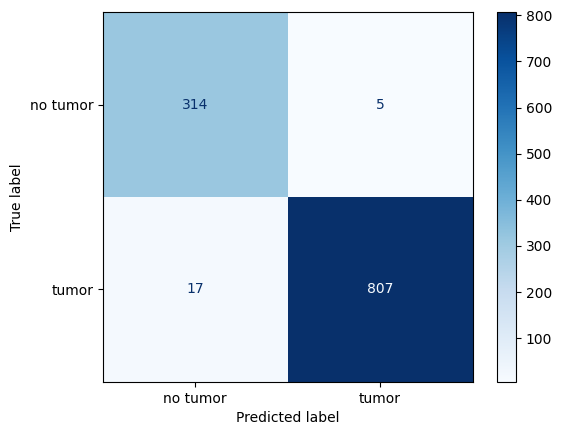

In [38]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch["tumor_presence"].numpy().astype(int).flatten())
    y_pred_type.extend((preds['tumor_presence'] > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no tumor", "tumor"])
disp.plot(cmap='Blues')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

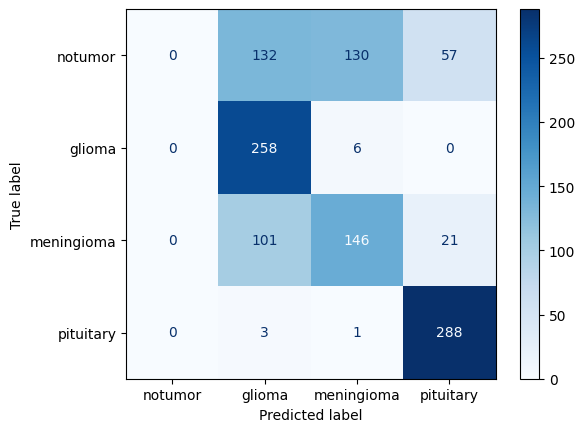

In [39]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_type'].numpy())
    y_pred_type.extend(preds['tumor_type'].argmax(axis=-1))

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')

### Grad-CAM

In [40]:
# grad-cam parameters
LAST_CONV_LAYER = "conv5_block16_2_conv"
BACKBONE_NAME = "densenet121"

In [67]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [68]:
def build_gradcam_model(model, head_name='tumor_presence'):
    """
    Build a Grad-CAM model directly connected to the backbone + frozen Conv2D layer.
    
    Args:
        model: Original multi-head model
        head_name: 'tumor_presence' or 'tumor_type'
    
    Returns:
        gradcam_model: tf.keras.Model with outputs [Top_Conv_Layer, selected head]
    """
    # Output of frozen Conv2D
    conv_layer = model.get_layer('Top_Conv_Layer').output

    # Output of the selected head
    if head_name == 'tumor_presence':
        head_output = model.get_layer('tumor_presence').output
    elif head_name == 'tumor_type':
        head_output = model.get_layer('tumor_type').output
    else:
        raise ValueError(f"Unknown head_name {head_name}")
    
    gradcam_model = Model(inputs=model.inputs, outputs=[conv_layer, head_output])
    return gradcam_model

In [145]:
def compute_gradcam_pp(gradcam_model, img, target_head_name):
    """
    Compute Grad-CAM++ heatmap for a single image.
    
    Args:
        gradcam_model: model with outputs [Top_Conv_Layer, target_head_output]
        img: tf.Tensor, shape (H,W,3) or (1,H,W,3)
    
    Returns:
        cam: numpy array, normalized heatmap
    """
    # Add batch dimension if necessary
    if len(img.shape) == 3:
        img = tf.expand_dims(img, axis=0)
    
    with tf.GradientTape() as tape:
        tape.watch(img)
        # Compute forward pass
        conv_outputs, preds = gradcam_model(img, training=False)
        
        # Select target for gradient
        if target_head_name == 'tumor_presence':
            loss = preds[:, 0]
        else:
            # For multi-class, pick max logit
            loss = tf.reduce_max(preds, axis=-1)
    
    # Gradients w.r.t. conv layer
    grads = tape.gradient(loss, conv_outputs)
    
    # Grad-CAM++ alpha weights
    alpha_num = grads ** 2
    alpha_denom = 2 * grads ** 2 + tf.reduce_sum(conv_outputs * grads ** 3, axis=(1,2), keepdims=True)
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
    alpha = alpha_num / alpha_denom
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2))
    cam = tf.reduce_sum(weights[:, tf.newaxis, tf.newaxis, :] * conv_outputs, axis=-1)
    
    # Normalize
    cam = tf.nn.relu(cam)
    cam = cam - tf.reduce_min(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = cam[0].numpy()  # remove batch dimension
    
    return cam

In [174]:
def overlay_gradcam(original_image, heatmap, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image, supports single or batched images.

    Args:
        original_image: numpy array or tf.Tensor, shape (H, W, 3) or (1, H, W, 3), values in [0,1]
        heatmap: numpy array or tf.Tensor, shape (h, w), values in [0,1]
        alpha: blending factor for overlay

    Returns:
        overlayed image, uint8, shape (H, W, 3)
    """
    # Convert TensorFlow tensors to numpy
    if isinstance(original_image, tf.Tensor):
        original_image = original_image.numpy()
    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()

    # Remove batch dimension if present
    if original_image.ndim == 4:
        original_image = original_image[0]

    # Ensure float32 and clip values
    original_image = np.clip(original_image.astype(np.float32), 0, 1)
    heatmap = np.clip(heatmap.astype(np.float32), 0, 1)

    # Resize heatmap to match original image
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    # Apply color map
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    #original_image -= original_image.min()
    #original_image /= (original_image.max() + 1e-8)
    # Overlay
    overlay = cv2.addWeighted(
        np.uint8(255 * original_image),
        1 - alpha,
        heatmap_colored,
        alpha,
        0
    )

    return overlay

In [156]:
def get_grad_cam_overlay_img(model, tensor_img, head_name='tumor_presence', grad_cam_function=compute_gradcam_pp):
    model.training = False
    gradcam_model = build_gradcam_model(model, head_name)
    
    # Ensure batch dimension
    if len(tensor_img.shape) == 3:
        tensor_img = tf.expand_dims(tensor_img, 0)
    
    image_tensor = tf.cast(tensor_img, tf.float32)
    image_tensor = tf.Variable(image_tensor)  # watch for gradients
    
    heatmap = grad_cam_function(
        gradcam_model,
        image_tensor,
        target_head_name=head_name
    )

    orig_img = image_tensor[0].numpy()
    overlay = overlay_gradcam(orig_img, heatmap)

    plt.imshow(orig_img)
    plt.title("Original")
    plt.axis("off")
    plt.show()
    
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")
    plt.show()


In [147]:
val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

In [148]:
def get_image_by_index(dataset, idx):
    flat_ds = dataset.unbatch()
    img = flat_ds.skip(idx).take(1)
    img = next(iter(img))[0]
    return tf.expand_dims(img, axis=0)

In [149]:
total_images = 0
for _ in val_ds.unbatch():
    total_images += 1

print("Total images:", total_images)


Total images: 1143


In [153]:
idx = 1121
test_img = get_image_by_index(val_ds, idx)
print(test_img.shape)

(1, 260, 260, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83084464..3.0091].


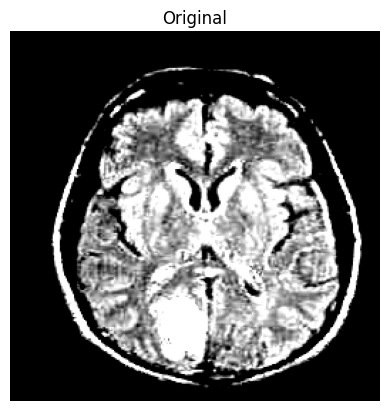

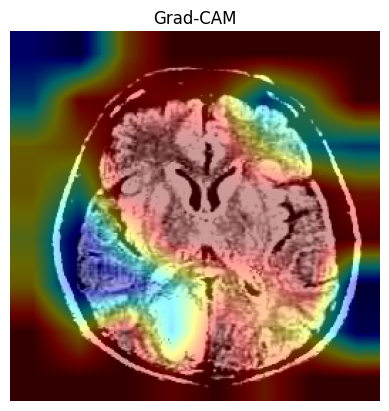

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83084464..3.0091].


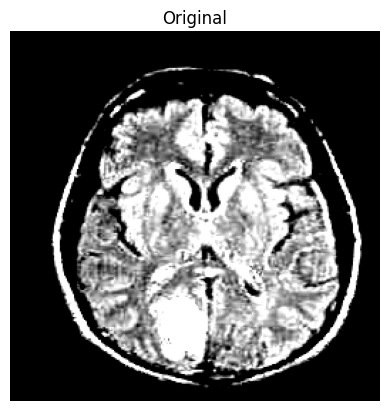

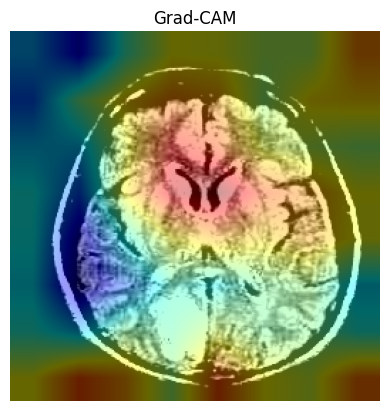

In [175]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_presence', grad_cam_function=compute_gradcam)
get_grad_cam_overlay_img(model, test_img, head_name='tumor_presence', grad_cam_function=compute_gradcam_pp)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83084464..3.0091].


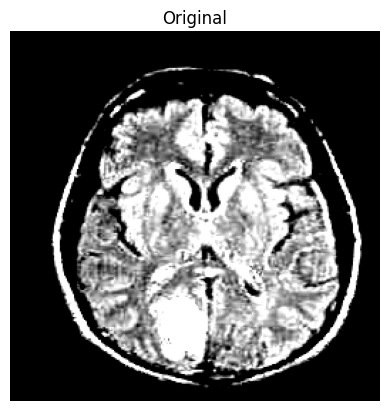

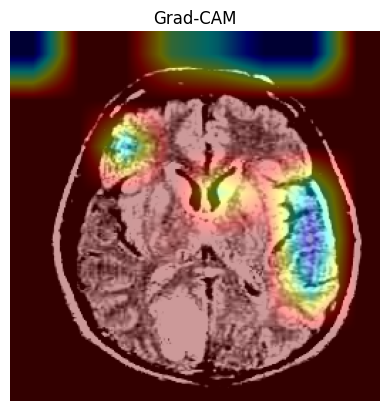

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.83084464..3.0091].


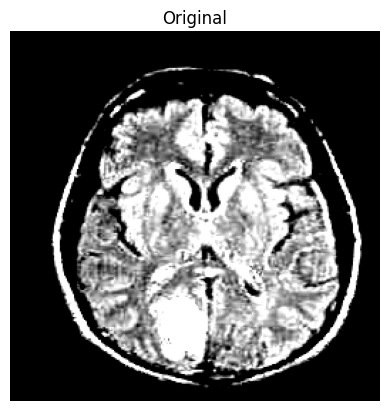

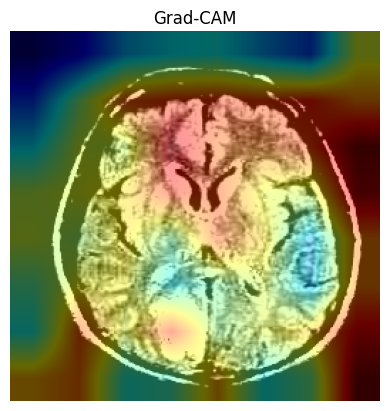

In [176]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_type', grad_cam_function=compute_gradcam)
get_grad_cam_overlay_img(model, test_img, head_name='tumor_type', grad_cam_function=compute_gradcam_pp)

In [75]:
def get_diagnosis(model):
    print("="*70)
    print("DIAGNOSTIC DU MODÈLE")
    print("="*70)
    
    # Afficher la structure
    print("\n1. STRUCTURE DES COUCHES:")
    for i, layer in enumerate(model.layers):
        print(f"  {i:2d}. {layer.name:35s} - {type(layer).__name__}")
    
    # Tester l'accès aux têtes
    print("\n2. TEST ACCÈS AUX TÊTES:")
    for head_name in ["tumor_presence", "tumor_type"]:
        try:
            head = model.get_layer(head_name)
            print(f"  ✅ {head_name}: trouvée, type={type(head).__name__}")
            
            # Si c'est un Sequential, afficher ses couches
            if hasattr(head, 'layers'):
                print(f"     Contient {len(head.layers)} sous-couches")
                for j, sublayer in enumerate(head.layers):
                    print(f"       {j}. {sublayer.name}")
        except Exception as e:
            print(f"  ❌ {head_name}: ERREUR - {e}")
    
    # Tester l'accès au backbone
    print("\n3. TEST ACCÈS AU BACKBONE:")
    try:
        backbone = model.get_layer("densenet121")
        print(f"  ✅ Backbone trouvé")
        
        # Trouver les dernières conv
        conv_layers = [l for l in backbone.layers if 'conv' in l.name]
        print(f"  Dernières couches conv:")
        for layer in conv_layers[-5:]:
            print(f"    - {layer.name}")
    except Exception as e:
        print(f"  ❌ ERREUR: {e}")
    
    # Tester un forward pass
    print("\n4. TEST FORWARD PASS:")
    test_input = tf.random.normal((1, 260, 260, 3))
    try:
        output = model(test_input, training=False)
        print(f"  ✅ Forward pass réussi")
        print(f"  Type output: {type(output)}")
        if isinstance(output, dict):
            for key, val in output.items():
                print(f"    '{key}': {val.shape}")
    except Exception as e:
        print(f"  ❌ ERREUR: {e}")
    
    print("\n" + "="*70)

In [76]:
"""
x = tf.random.normal((1,260,260,3))
y = model(x)
print(type(y))
"""

'\nx = tf.random.normal((1,260,260,3))\ny = model(x)\nprint(type(y))\n'

In [77]:
"""
grad_model = build_gradcam_model(
    model,
    BACKBONE_NAME,
    LAST_CONV_LAYER
)

heatmap = make_gradcam_multihead(
    grad_model,
    test_img,
    head_name="tumor_presence"
)

print("✅ GradCAM++ OK")
print(heatmap.shape)
"""

'\ngrad_model = build_gradcam_model(\n    model,\n    BACKBONE_NAME,\n    LAST_CONV_LAYER\n)\n\nheatmap = make_gradcam_multihead(\n    grad_model,\n    test_img,\n    head_name="tumor_presence"\n)\n\nprint("✅ GradCAM++ OK")\nprint(heatmap.shape)\n'

In [78]:
"""
# --- Exemple d'utilisation ---
orig_img = test_img[0].numpy()  # tf.Tensor -> numpy
orig_img = orig_img.astype("float32")
orig_img -= orig_img.min()
orig_img /= (orig_img.max() + 1e-8)
orig_img = (orig_img * 255).astype("uint8")

superposed = overlay_heatmap_on_image(orig_img, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(superposed[..., ::-1])  
plt.axis('off')
plt.title("Grad-CAM++ Superposed")
plt.show()
"""

'\n# --- Exemple d\'utilisation ---\norig_img = test_img[0].numpy()  # tf.Tensor -> numpy\norig_img = orig_img.astype("float32")\norig_img -= orig_img.min()\norig_img /= (orig_img.max() + 1e-8)\norig_img = (orig_img * 255).astype("uint8")\n\nsuperposed = overlay_heatmap_on_image(orig_img, heatmap)\n\nplt.figure(figsize=(6,6))\nplt.imshow(superposed[..., ::-1])  \nplt.axis(\'off\')\nplt.title("Grad-CAM++ Superposed")\nplt.show()\n'

### Grad-CAM for confusion matrix categories

## Fine-Tuning

In [79]:
Warning : do not forget :
- grad-cam
- grad-cam++
- Med pipeline ? 
- Uncertainty-weighted CAM ?
- CAM sur faux positifs
- CAM sur faux négatifs
- stratégie de fine-tuning du backbone
- BatchNormalization precaution in fine-tuning

SyntaxError: invalid syntax (172334716.py, line 1)